# Document parsing with MinerU 2.5 and OpenVINO

[MinerU 2.5](https://github.com/opendatalab/MinerU) is a state-of-the-art document parsing engine maintained by [OpenDataLab](https://opendatalab.com/). Its 2.5 generation is built around a single 1.2 B parameter vision–language model — [`opendatalab/MinerU2.5-Pro-2604-1.2B`](https://huggingface.co/opendatalab/MinerU2.5-Pro-2604-1.2B) — that converts page images into structured Markdown / JSON in **two prompted steps**:

1. **Layout detection** — the whole page is sent to the model with the prompt `Layout Detection:`. The model emits special `<|box_start|>… <|box_end|><|ref_start|>type<|ref_end|>` tokens that describe every region's bounding box and type (text, title, table, formula, image, chart, …).
2. **Per-region content recognition** — every region is cropped and sent back with a region-specific prompt (`Text Recognition:`, `Table Recognition:`, `Formula Recognition:`, `Image Analysis:`).

On top of those two passes, a small post-processing layer fixes equation delimiters, normalises tables to HTML/OTSL, merges truncated paragraphs and finally renders Markdown via `json2md`.

The model itself is a Qwen2-VL architecture, so it can be exported to OpenVINO IR exactly like in the [`qwen2-vl`](../qwen2-vl/qwen2-vl.ipynb) notebook. In this tutorial we:

* convert and 4-bit weight-compress `MinerU2.5-Pro-2604-1.2B` with [Optimum Intel](https://github.com/huggingface/optimum-intel),
* run inference with [OpenVINO GenAI](https://github.com/openvinotoolkit/openvino.genai)'s `VLMPipeline`,
* drive the MinerU two-step pipeline through a small `OVMinerUClient` wrapper that reuses the official post-processing utilities,
* and expose the whole thing as a tiny Gradio document-to-Markdown demo.

#### Table of contents:
- [Prerequisites](#Prerequisites)
- [Convert and Optimize model](#Convert-and-Optimize-model)
- [Select inference device](#Select-inference-device)
- [Build the OpenVINO MinerU client](#Build-the-OpenVINO-MinerU-client)
- [Run document parsing on a sample page](#Run-document-parsing-on-a-sample-page)
- [Parse a multi-page PDF](#Parse-a-multi-page-PDF)
- [Interactive Demo](#Interactive-Demo)

### Installation Instructions

This is a self-contained example that relies solely on its own code.

We recommend  running the notebook in a virtual environment. You only need a Jupyter server to start.
For details, please refer to [Installation Guide](https://github.com/openvinotoolkit/openvino_notebooks/blob/latest/README.md#-installation-guide).


<img referrerpolicy="no-referrer-when-downgrade" src="https://static.scarf.sh/a.png?x-pxid=5b5a4db0-7875-4bfb-bdbd-01698b5b1a77&file=notebooks/mineru2.5/mineru2.5.ipynb" />

## Prerequisites
[back to top ⬆️](#Table-of-contents)

In [1]:
%pip uninstall -q -y optimum optimum-intel optimum-onnx
%pip install -q -U "nncf>=2.15.0" "torch>=2.7" "torchvision>=0.22" "transformers>=4.53" "peft>=0.15.0" "Pillow" "pypdfium2" "gradio>=4.36,<6" --extra-index-url https://download.pytorch.org/whl/cpu
%pip install -q -U "openvino>=2026.0.0" "openvino-tokenizers>=2026.0.0" "openvino-genai>=2026.0.0"
%pip install -q --upgrade-strategy eager "optimum[openvino]>=1.26.0" --extra-index-url https://download.pytorch.org/whl/cpu
%pip install -q "mineru-vl-utils>=0.2.7"

Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hf-gradio 0.4.1 requires gradio-client<3.0,>=2.0, but you have gradio-client 1.14.0 which is incompatible.

[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: D:\optimum-intel\py_env\Scripts\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: D:\optimum-intel\py_env\Scripts\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hf-gradio 0.4.1 requires gradio-client<3.0,>=2.0, but you have gradio-client 1.14.0 which is incompatible.

[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: D:\optimum-intel\py_env\Scripts\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: D:\optimum-intel\py_env\Scripts\python.exe -m pip install --upgrade pip


In [2]:
from pathlib import Path
import requests

if not Path("cmd_helper.py").exists():
    r = requests.get(url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/cmd_helper.py")
    open("cmd_helper.py", "w").write(r.text)

if not Path("notebook_utils.py").exists():
    r = requests.get(url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/notebook_utils.py")
    open("notebook_utils.py", "w").write(r.text)

# Read more about telemetry collection at https://github.com/openvinotoolkit/openvino_notebooks?tab=readme-ov-file#-telemetry
from notebook_utils import collect_telemetry

collect_telemetry("mineru2.5.ipynb")

## Convert and Optimize model
[back to top ⬆️](#Table-of-contents)

MinerU 2.5 ships as a PyTorch checkpoint with the `Qwen2VLForConditionalGeneration` architecture. We use the OpenVINO export integrated in 🤗 [Optimum Intel](https://huggingface.co/docs/optimum/intel/index) to convert the model to OpenVINO IR.

The general command is:

```bash
optimum-cli export openvino --model <model_id_or_path> --task <task> <output_dir>
```

We additionally compress the weights to **INT4** with [NNCF](https://github.com/openvinotoolkit/nncf). Weight-only quantization preserves activations in floating point and is the recommended optimization for memory-bound LLMs/VLMs. See the [OpenVINO weight compression guide](https://docs.openvino.ai/2024/openvino-workflow/model-optimization-guide/weight-compression.html) for more details. You can switch to `fp16` below if you prefer the reference precision.

<details>
    <summary><b>Click here for more details about weight compression</b></summary>

Weight compression aims to reduce the memory footprint of a model. It can also lead to significant performance improvement for large memory-bound models, such as Large Language Models (LLMs). LLMs and other models, which require extensive memory to store the weights during inference, can benefit from weight compression in the following ways:

* enabling the inference of exceptionally large models that cannot be accommodated in the memory of the device;
* improving the inference performance of the models by reducing the latency of the memory access when computing the operations with weights, for example, Linear layers.

[Neural Network Compression Framework (NNCF)](https://github.com/openvinotoolkit/nncf) provides 4-bit / 8-bit mixed weight quantization as a compression method primarily designed to optimize LLMs.
</details>

In [3]:
import ipywidgets as widgets

weight_format = widgets.Dropdown(
    options=["int4", "fp16"],
    value="int4",
    description="Weights:",
)
weight_format

Dropdown(description='Weights:', options=('int4', 'fp16'), value='int4')

In [4]:
import json
import shutil
from huggingface_hub import snapshot_download
from cmd_helper import optimum_cli

pt_model_id = "opendatalab/MinerU2.5-Pro-2604-1.2B"
model_dir = Path(pt_model_id.split("/")[-1]) / weight_format.value.upper()

# Download a local snapshot so we can patch the config before exporting.
# The HF checkpoint sets ``tie_word_embeddings`` only inside ``text_config``;
# transformers v5 reads the top-level value (default ``False``) and therefore
# fails to tie ``lm_head.weight`` to ``embed_tokens.weight``, producing a
# randomly initialised LM head and gibberish output. Adding the flag at the
# top level fixes the export.
snap_dir = Path(snapshot_download(pt_model_id))
patched_dir = Path("./hf_snapshot") / pt_model_id.split("/")[-1]
if not patched_dir.exists():
    shutil.copytree(snap_dir, patched_dir)
    cfg_path = patched_dir / "config.json"
    cfg = json.loads(cfg_path.read_text(encoding="utf-8"))
    if not cfg.get("tie_word_embeddings"):
        cfg["tie_word_embeddings"] = True
        cfg_path.write_text(json.dumps(cfg, indent=2, ensure_ascii=False), encoding="utf-8")

if not model_dir.exists():
    optimum_cli(str(patched_dir), model_dir, additional_args={"task": "image-text-to-text", "weight-format": weight_format.value})

# Patch the OpenVINO detokenizer so MinerU layout tokens (<|box_start|>, etc.)
# survive decoding (they are marked special=True in the HF tokenizer config and
# would otherwise be stripped from the generated text).
from ov_mineru_helper import patch_detokenizer_for_mineru

patch_detokenizer_for_mineru(model_dir, patched_dir)

print(f"OpenVINO model is ready at: {model_dir.resolve()}")

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

**Export command:**

`optimum-cli export openvino --model hf_snapshot\MinerU2.5-Pro-2604-1.2B MinerU2.5-Pro-2604-1.2B\INT4 --task image-text-to-text --weight-format int4`

OpenVINO model is ready at: D:\openvino_notebooks\notebooks\mineru2.5\MinerU2.5-Pro-2604-1.2B\INT4


## Select inference device
[back to top ⬆️](#Table-of-contents)

In [5]:
from notebook_utils import device_widget

device = device_widget(default="AUTO", exclude=["NPU"])
device

Dropdown(description='Device:', index=2, options=('CPU', 'GPU', 'AUTO'), value='AUTO')

## Build the OpenVINO MinerU client
[back to top ⬆️](#Table-of-contents)

`OVMinerUClient` wraps an `openvino_genai.VLMPipeline` and reproduces the official MinerU two-step pipeline:
* `prepare_for_layout` resizes the page to 1036×1036 and asks the VLM to emit the layout description;
* `parse_layout_output` regex-decodes the bounding boxes and region types;
* `prepare_for_extract` crops every region with the proper rotation / table-image masking and assembles the per-region prompts and sampling parameters;
* finally `post_process` from `mineru_vl_utils` cleans up equations, tables and paragraphs.

The whole post-processing layer is reused from the official `mineru-vl-utils` package — only the model call is swapped for OpenVINO.

In [6]:
if not Path("ov_mineru_helper.py").exists():
    r = requests.get(url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/notebooks/mineru2.5/ov_mineru_helper.py")
    open("ov_mineru_helper.py", "w").write(r.text)

if not Path("gradio_helper.py").exists():
    r = requests.get(url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/notebooks/mineru2.5/gradio_helper.py")
    open("gradio_helper.py", "w").write(r.text)

from ov_mineru_helper import OVMinerUClient

client = OVMinerUClient(model_dir=model_dir, device=device.value)

## Run document parsing on a sample page
[back to top ⬆️](#Table-of-contents)

We download a single document image from the official MinerU repository, run the two-step pipeline, and display both the detected layout and the resulting Markdown.

Sample page size: (1512, 2064)


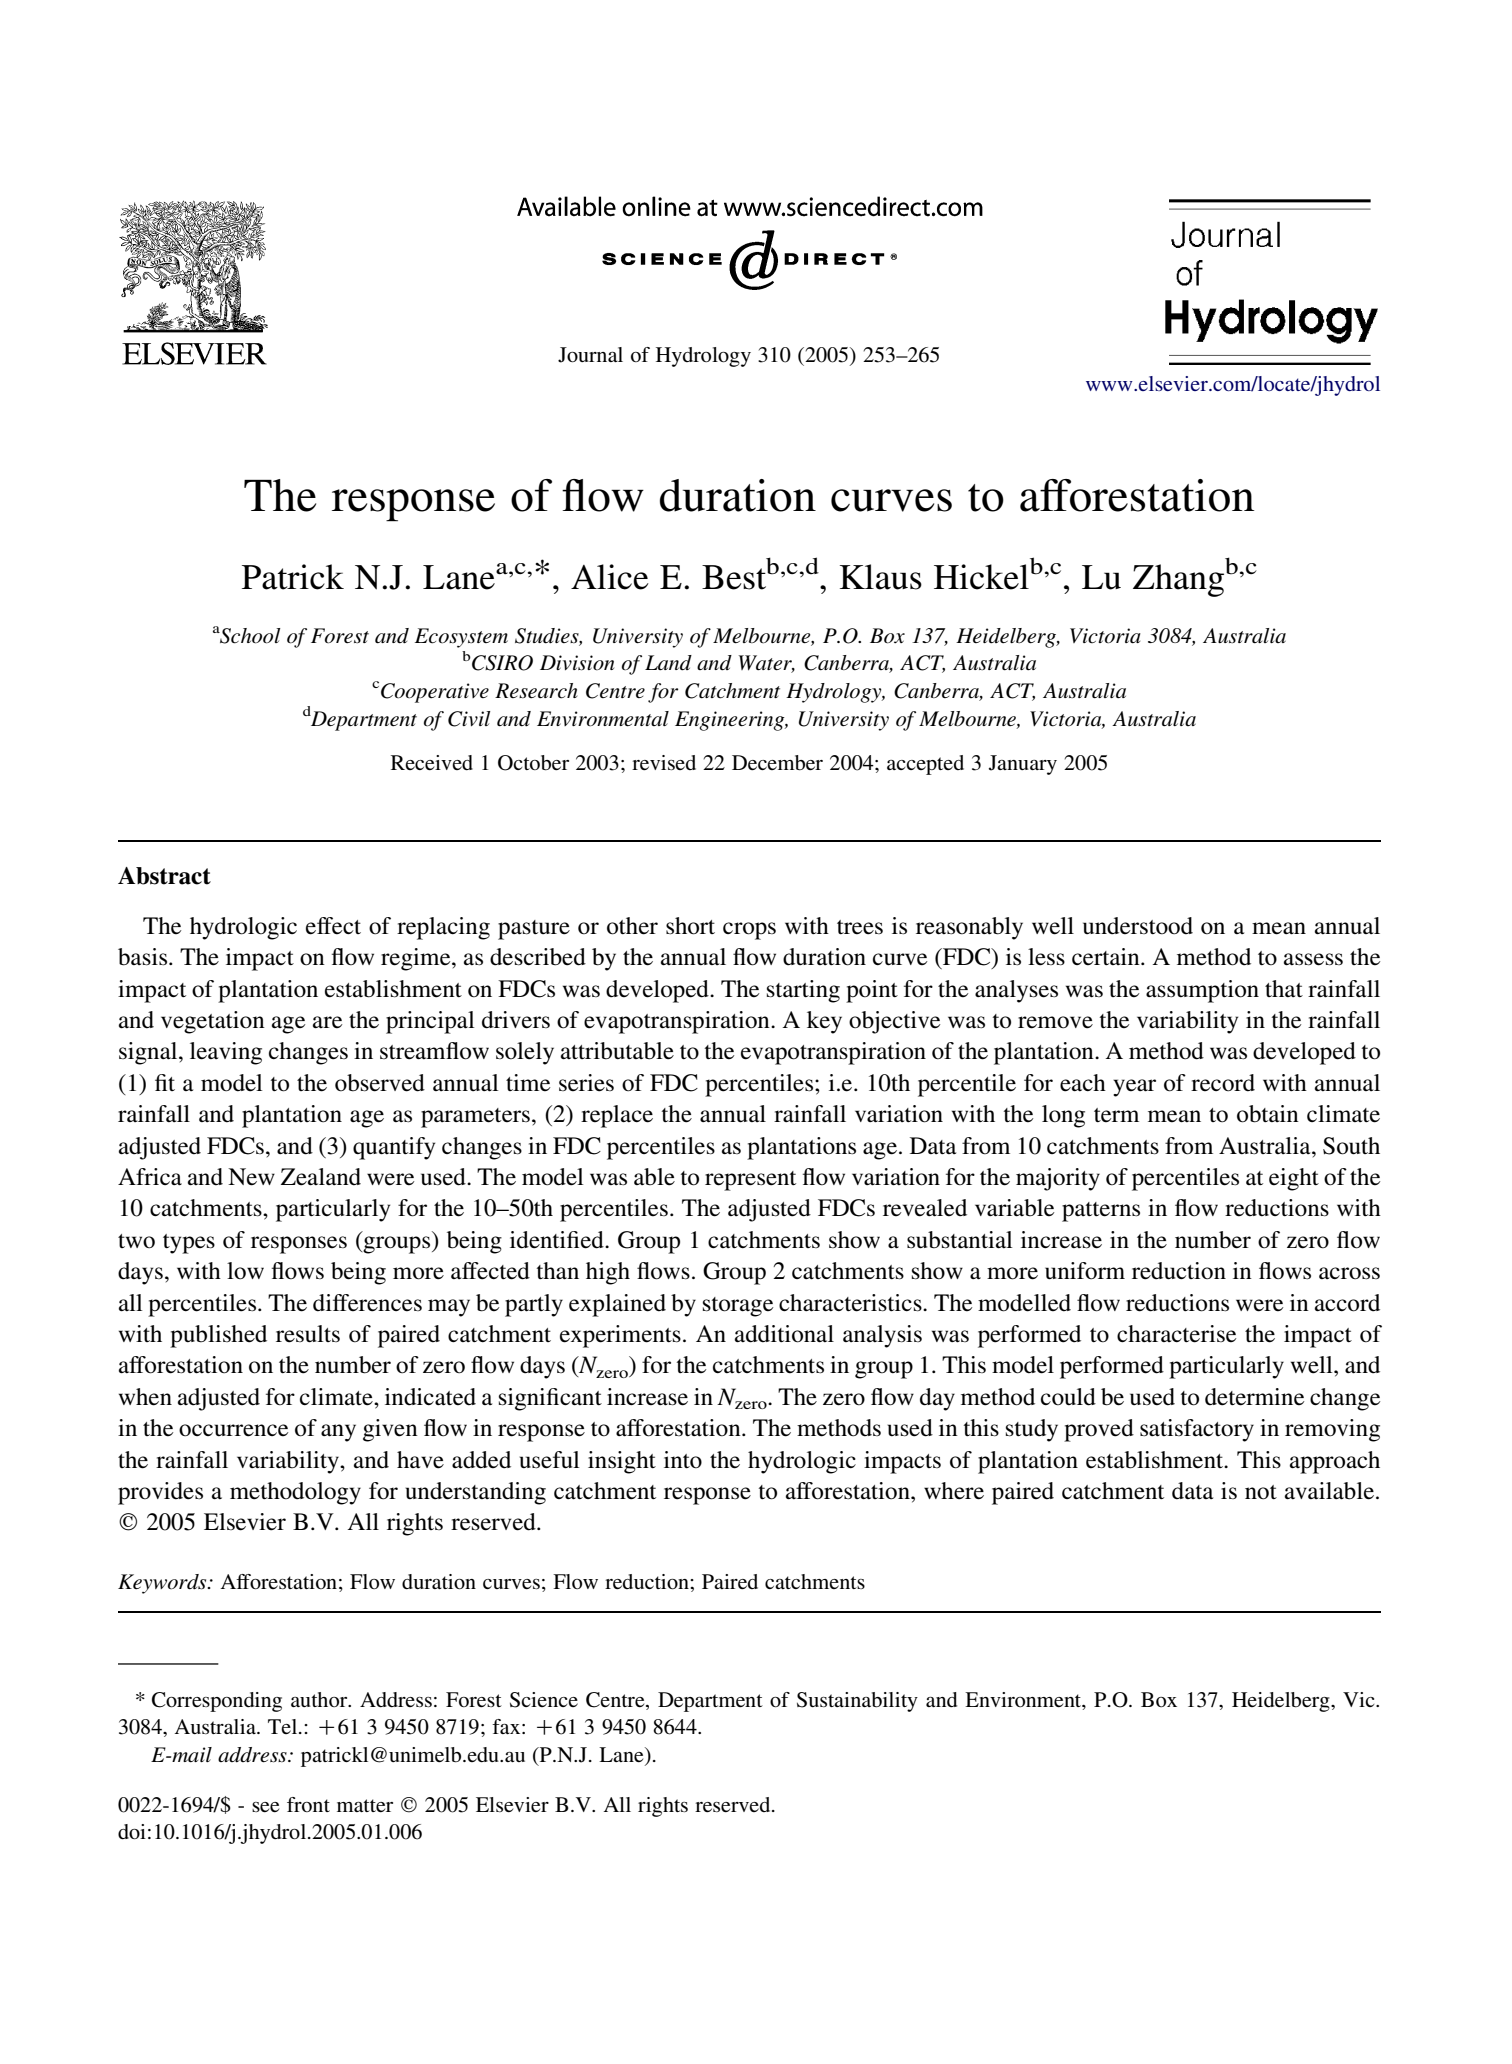

In [ ]:
from IPython.display import Markdown, display

sample_url = "https://raw.githubusercontent.com/opendatalab/MinerU/master/demo/pdfs/demo1.pdf"
sample_pdf = Path("sample.pdf")
if not sample_pdf.exists():
    sample_pdf.write_bytes(requests.get(sample_url, timeout=60).content)

from ov_mineru_helper import pdf_to_images, render_blocks_overlay

pages = pdf_to_images(sample_pdf, dpi=200)
page = pages[0]
print(f"Sample page size: {page.size}")
page

In [8]:
markdown, blocks = client.image_to_markdown(page)

print(f"Detected {len(blocks)} layout blocks. Block types:")
for b in blocks:
    print(f"  - {b['type']:<14}  bbox={[round(c, 3) for c in b['bbox']]}")

Detected 18 layout blocks. Block types:
  - header          bbox=[0.078, 0.095, 0.177, 0.177]
  - header          bbox=[0.339, 0.092, 0.652, 0.107]
  - header          bbox=[0.395, 0.109, 0.594, 0.141]
  - header          bbox=[0.366, 0.165, 0.622, 0.178]
  - header          bbox=[0.715, 0.095, 0.914, 0.193]
  - title           bbox=[0.157, 0.228, 0.83, 0.253]
  - text            bbox=[0.155, 0.268, 0.832, 0.291]
  - text            bbox=[0.136, 0.3, 0.852, 0.314]
  - text            bbox=[0.303, 0.314, 0.687, 0.327]
  - text            bbox=[0.244, 0.328, 0.746, 0.341]
  - text            bbox=[0.198, 0.341, 0.792, 0.355]
  - text            bbox=[0.253, 0.362, 0.734, 0.376]
  - title           bbox=[0.074, 0.417, 0.142, 0.43]
  - text            bbox=[0.072, 0.441, 0.916, 0.744]
  - text            bbox=[0.073, 0.759, 0.574, 0.773]
  - page_footnote   bbox=[0.072, 0.816, 0.916, 0.842]
  - page_footnote   bbox=[0.098, 0.843, 0.435, 0.857]
  - footer          bbox=[0.072, 0.867, 0.514,

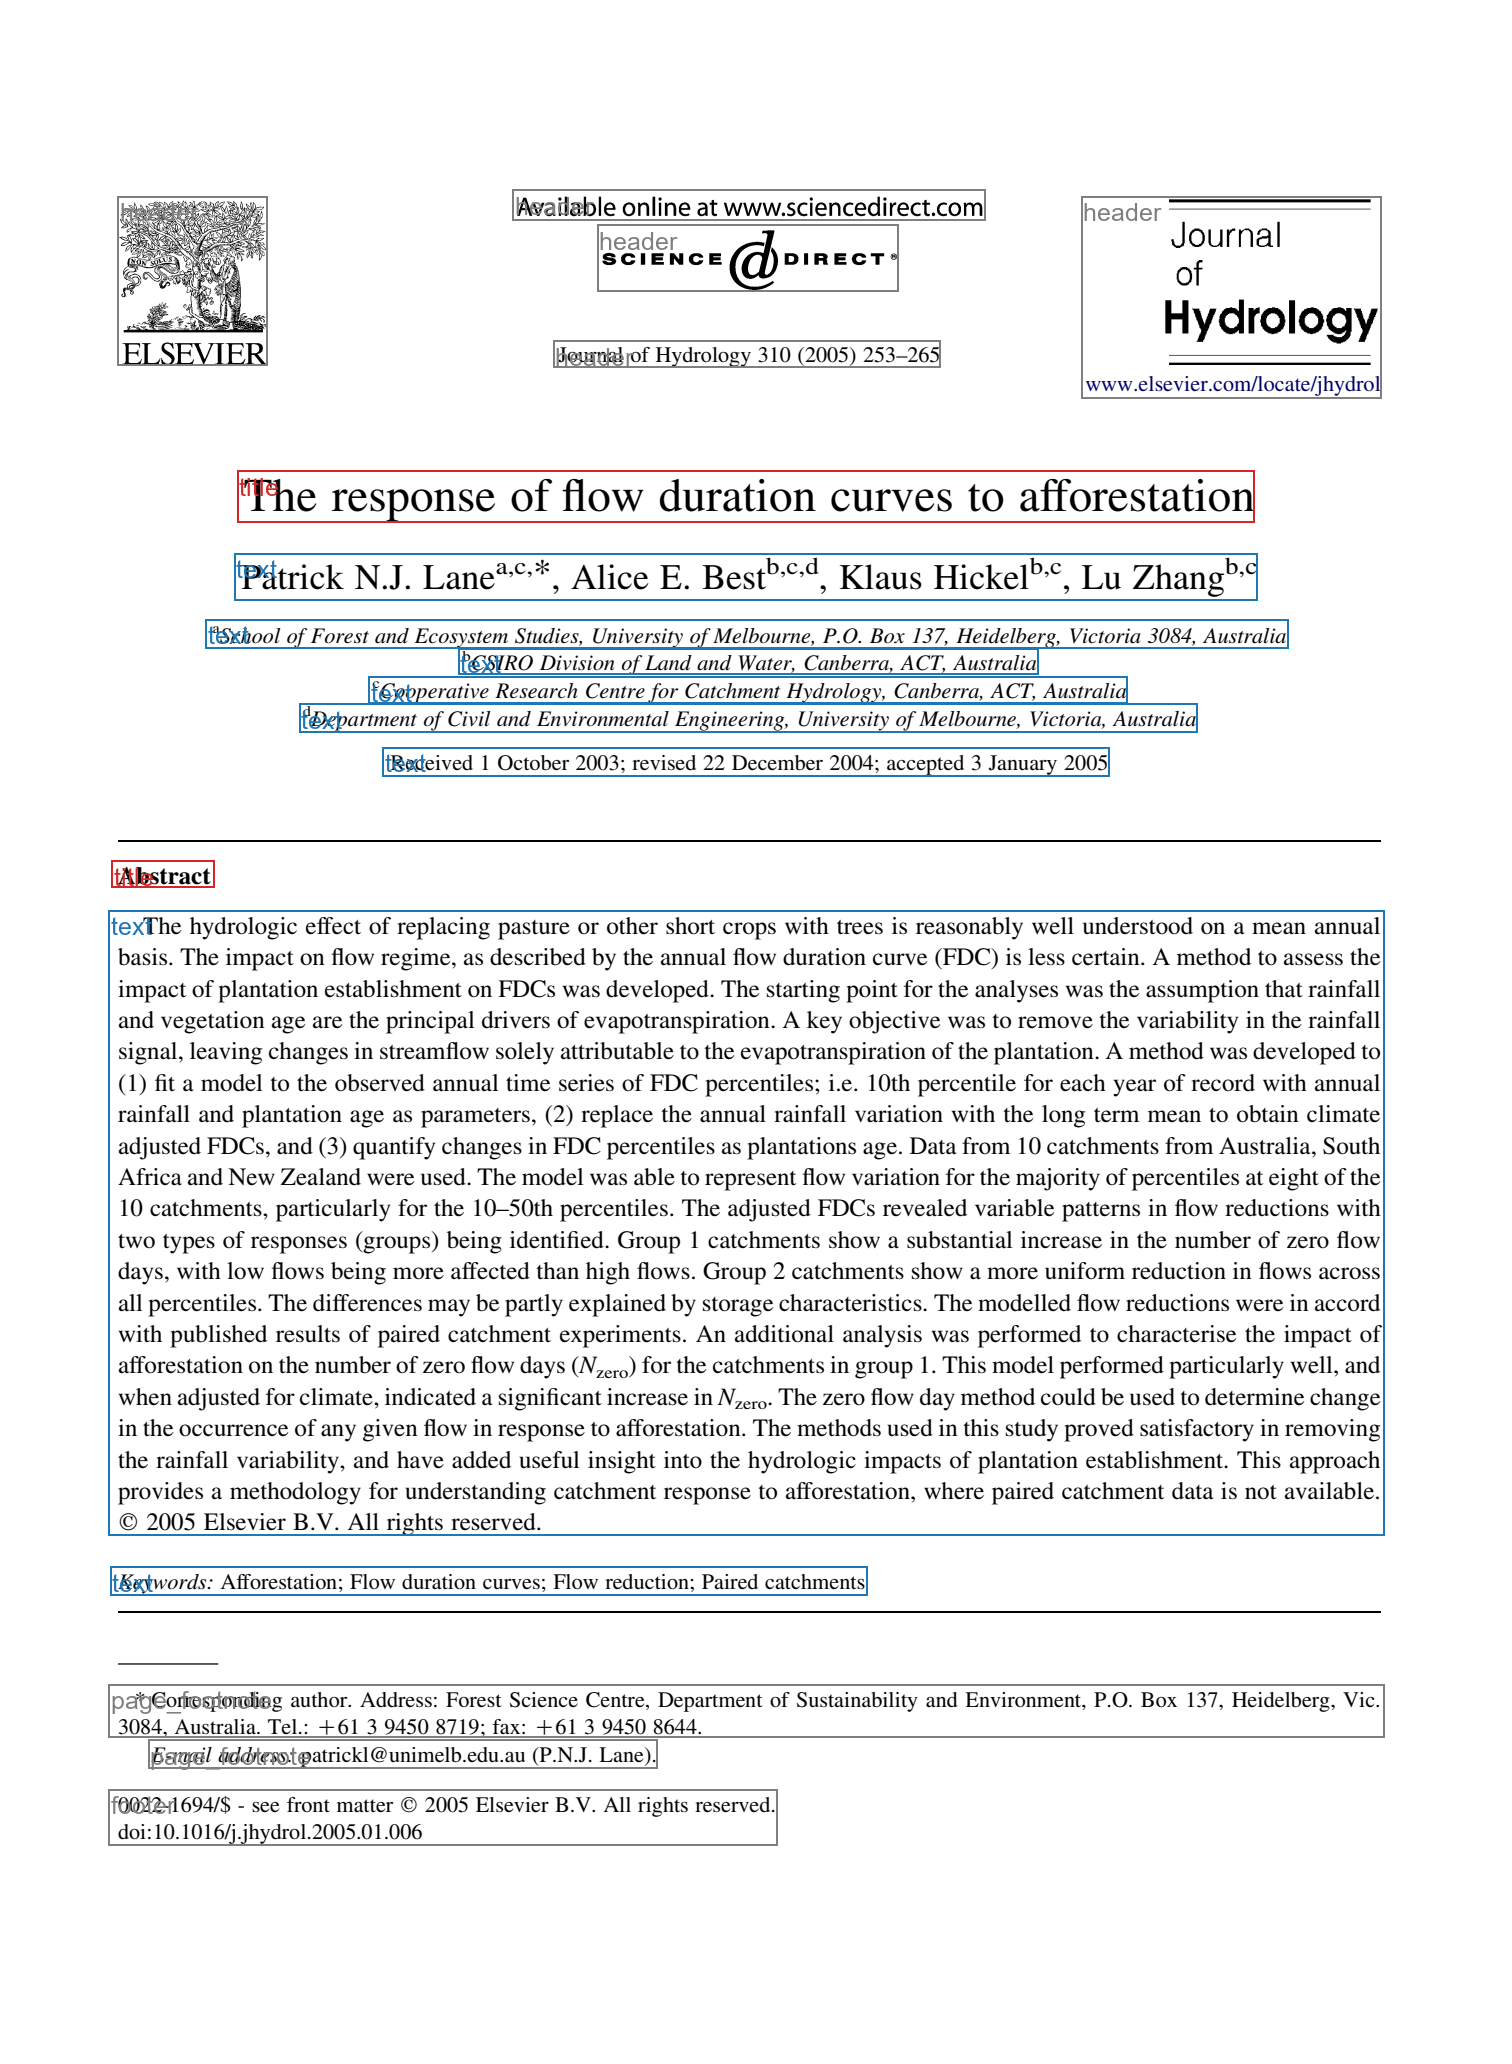

In [9]:
render_blocks_overlay(page, blocks)

In [10]:
display(Markdown(markdown))

ELSEVIER

Available online at www.sciencedirect.com

SCIENCE @DIRECT®

Journal of Hydrology 310 (2005) 253–265

Journal of Hydrology
www.elsevier.com/locate/jhydrol

The response of flow duration curves to afforestation

Patrick N.J. Lane \( ^{a,c,*} \) , Alice E. Best \( ^{b,c,d} \) , Klaus Hickel \( ^{b,c} \) , Lu Zhang \( ^{b,c} \)

\(^{a}\)School of Forest and Ecosystem Studies, University of Melbourne, P.O. Box 137, Heidelberg, Victoria 3084, Australia

\( ^{b} \) CSIRO Division of Land and Water, Canberra, ACT, Australia

\( ^{c} \) Cooperative Research Centre for Catchment Hydrology, Canberra, ACT, Australia

\( ^{d} \) Department of Civil and Environmental Engineering, University of Melbourne, Victoria, Australia

Received 1 October 2003; revised 22 December 2004; accepted 3 January 2005

Abstract

The hydrologic effect of replacing pasture or other short crops with trees is reasonably well understood on a mean annual basis. The impact on flow regime, as described by the annual flow duration curve (FDC) is less certain. A method to assess the impact of plantation establishment on FDCs was developed. The starting point for the analyses was the assumption that rainfall and vegetation age are the principal drivers of evapotranspiration. A key objective was to remove the variability in the rainfall signal, leaving changes in streamflow solely attributable to the evapotranspiration of the plantation. A method was developed to (1) fit a model to the observed annual time series of FDC percentiles; i.e. 10th percentile for each year of record with annual rainfall and plantation age as parameters, (2) replace the annual rainfall variation with the long term mean to obtain climate adjusted FDCs, and (3) quantify changes in FDC percentiles as plantations age. Data from 10 catchments from Australia, South Africa and New Zealand were used. The model was able to represent flow variation for the majority of percentiles at eight of the 10 catchments, particularly for the 10–50th percentiles. The adjusted FDCs revealed variable patterns in flow reductions with two types of responses (groups) being identified. Group 1 catchments show a substantial increase in the number of zero flow days, with low flows being more affected than high flows. Group 2 catchments show a more uniform reduction in flows across all percentiles. The differences may be partly explained by storage characteristics. The modelled flow reductions were in accord with published results of paired catchment experiments. An additional analysis was performed to characterise the impact of afforestation on the number of zero flow days ( \( N_{zero} \) ) for the catchments in group 1. This model performed particularly well, and when adjusted for climate, indicated a significant increase in  \( N_{zero} \) . The zero flow day method could be used to determine change in the occurrence of any given flow in response to afforestation. The methods used in this study proved satisfactory in removing the rainfall variability, and have added useful insight into the hydrologic impacts of plantation establishment. This approach provides a methodology for understanding catchment response to afforestation, where paired catchment data is not available. © 2005 Elsevier B.V. All rights reserved.

Keywords: Afforestation; Flow duration curves; Flow reduction; Paired catchments

* Corresponding author. Address: Forest Science Centre, Department of Sustainability and Environment, P.O. Box 137, Heidelberg, Vic. 3084, Australia. Tel.: +61 3 9450 8719; fax: +61 3 9450 8644.

E-mail address: patrickl@unimelb.edu.au (P.N.J. Lane).

0022-1694/$ - see front matter © 2005 Elsevier B.V. All rights reserved. doi:10.1016/j.jhydrol.2005.01.006

## Parse a multi-page PDF
[back to top ⬆️](#Table-of-contents)

`OVMinerUClient.pdf_to_markdown` rasterises every page with [pypdfium2](https://github.com/pypdfium2-team/pypdfium2) and runs the two-step pipeline on each one. Pages are joined with horizontal rules in the resulting Markdown.

> **Note on images and tables:**
> - **Tables** are always recognised (OTSL → HTML conversion) and appear in the Markdown output.
> - **Images/charts** are skipped by default (`image_analysis=False`) — this matches the official MinerU 2.5 pipeline behaviour. To enable image/chart descriptions, pass `image_analysis=True` to `image_to_markdown()` or `pdf_to_markdown()` (see the Interactive Demo below for a toggle).

In [11]:
def _progress(i, total):
    print(f"[{i}/{total}] processed")


full_md, _ = client.pdf_to_markdown(sample_pdf, dpi=200, progress_callback=_progress)
print(f"Total Markdown length: {len(full_md)} characters")

[0/13] processed
[1/13] processed
[2/13] processed
[3/13] processed
[4/13] processed
[5/13] processed
[6/13] processed
[7/13] processed
[8/13] processed
[9/13] processed
[10/13] processed
[11/13] processed
[12/13] processed
[13/13] processed
Total Markdown length: 43454 characters


In [13]:
display(Markdown(full_md[:8000] + ("…" if len(full_md) > 8000 else "")))

ELSEVIER

Available online at www.sciencedirect.com

SCIENCE @DIRECT®

Journal of Hydrology 310 (2005) 253–265

Journal of Hydrology
www.elsevier.com/locate/jhydrol

The response of flow duration curves to afforestation

Patrick N.J. Lane \( ^{a,c,*} \) , Alice E. Best \( ^{b,c,d} \) , Klaus Hickel \( ^{b,c} \) , Lu Zhang \( ^{b,c} \)

\(^{a}\)School of Forest and Ecosystem Studies, University of Melbourne, P.O. Box 137, Heidelberg, Victoria 3084, Australia

\( ^{b} \) CSIRO Division of Land and Water, Canberra, ACT, Australia

\( ^{c} \) Cooperative Research Centre for Catchment Hydrology, Canberra, ACT, Australia

\( ^{d} \) Department of Civil and Environmental Engineering, University of Melbourne, Victoria, Australia

Received 1 October 2003; revised 22 December 2004; accepted 3 January 2005

Abstract

The hydrologic effect of replacing pasture or other short crops with trees is reasonably well understood on a mean annual basis. The impact on flow regime, as described by the annual flow duration curve (FDC) is less certain. A method to assess the impact of plantation establishment on FDCs was developed. The starting point for the analyses was the assumption that rainfall and vegetation age are the principal drivers of evapotranspiration. A key objective was to remove the variability in the rainfall signal, leaving changes in streamflow solely attributable to the evapotranspiration of the plantation. A method was developed to (1) fit a model to the observed annual time series of FDC percentiles; i.e. 10th percentile for each year of record with annual rainfall and plantation age as parameters, (2) replace the annual rainfall variation with the long term mean to obtain climate adjusted FDCs, and (3) quantify changes in FDC percentiles as plantations age. Data from 10 catchments from Australia, South Africa and New Zealand were used. The model was able to represent flow variation for the majority of percentiles at eight of the 10 catchments, particularly for the 10–50th percentiles. The adjusted FDCs revealed variable patterns in flow reductions with two types of responses (groups) being identified. Group 1 catchments show a substantial increase in the number of zero flow days, with low flows being more affected than high flows. Group 2 catchments show a more uniform reduction in flows across all percentiles. The differences may be partly explained by storage characteristics. The modelled flow reductions were in accord with published results of paired catchment experiments. An additional analysis was performed to characterise the impact of afforestation on the number of zero flow days ( \( N_{zero} \) ) for the catchments in group 1. This model performed particularly well, and when adjusted for climate, indicated a significant increase in  \( N_{zero} \) . The zero flow day method could be used to determine change in the occurrence of any given flow in response to afforestation. The methods used in this study proved satisfactory in removing the rainfall variability, and have added useful insight into the hydrologic impacts of plantation establishment. This approach provides a methodology for understanding catchment response to afforestation, where paired catchment data is not available. © 2005 Elsevier B.V. All rights reserved.

Keywords: Afforestation; Flow duration curves; Flow reduction; Paired catchments

* Corresponding author. Address: Forest Science Centre, Department of Sustainability and Environment, P.O. Box 137, Heidelberg, Vic. 3084, Australia. Tel.: +61 3 9450 8719; fax: +61 3 9450 8644.

E-mail address: patrickl@unimelb.edu.au (P.N.J. Lane).

0022-1694/$ - see front matter © 2005 Elsevier B.V. All rights reserved. doi:10.1016/j.jhydrol.2005.01.006

---

254

P.N.J. Lane et al. / Journal of Hydrology 310 (2005) 253–265

1. Introduction

Widespread afforestation through plantation establishment on non-forested land represents a potentially significant alteration of catchment evapotranspiration (ET). Using data collated from multiple catchment studies, researchers have demonstrated a consistent difference in ET between forests and grass or short crops, and the relationship between ET and rainfall on a mean annual basis (Holmes and Sinclair, 1986; Vertessy and Bessard, 1999; Zhang et al., 1999, 2001). Once annual rainfall exceeds 400–500 mm, there is an increasing divergence between forest and grassland ET (Zhang et al., 2001). Research from South Africa in particular has demonstrated flow reduction following afforestation with both pine and eucalypt species (Bosch, 1979; Van Lill et al., 1980; Van Wyk, 1987; Bosch and Von Gadow, 1990; Scott and Smith, 1997; Scott et al., 2000). In regions, where water is an increasingly valuable resource, prediction of the long-term hydrologic impact of afforestation is a prerequisite for the optimal planning of catchment land use.

Zhang et al. (1999, 2001) developed simple and easily parameterised models to predict changes in mean annual flows following afforestation. However, there is a need to consider the annual flow regime as the relative changes in high and low flows may have considerable site specific and downstream impacts. Sikka et al. (2003) recently showed a change from grassland to Eucalyptus globulus plantations in India decreased a low flow index by a factor of two during the first rotation (9 years), and by 3.75 during the second rotation, with more subdued impact on peak flows. The index was defined as the 10 day average flow exceeded 95% of the time, obtained from analysis of 10-day flow duration curves. Scott and Smith (1997) reported proportionally greater reductions in low flows (75–100th percentiles) than annual flows from South African research catchments under conversions from grass to pine and eucalypt plantations, while Bosch (1979) found the greatest reduction in seasonal flow from the summer wet season. Fahey and Jackson (1997) reported the reduction in peak flows was twice that of total flow and low flows for pine afforestation in New Zealand. The generalisations that can be drawn from annual analyses, where processes and hydrologic responses are to a certain extent integrated may not

Fig. 1. Annual flow duration curves of daily flows from Pine Creek, Australia, 1989–2000.

apply on a seasonal or shorter scale. Further, the observed impacts of any land use change on flows may be exaggerated or understated depending on the prevailing climate. Observations of flow during extended wet or dry spells, or with high annual variability can obscure the real impacts. Fig. 1 plots annual FDCs over 12 years of plantation growth for one of the catchments used in this study, Pine Creek. The net change in flow is obscured by rainfall variability; e.g. the greatest change in the FDC is in 1996, with the stream flowing \(< 20\%\) of the time. This may be compared with 2000, where there is substantially higher flows.

This paper presents the results of a project aimed at quantifying changes in annual flow regime of catchments following plantation establishment. The flow regime is represented by the flow duration curve (FDC). The key assumption was that rainfall and forest age are the principal drivers of evapotranspiration. For any generalisation of response of the FDC to vegetation change, the variation in the annual climate signal must be removed. The time-tested solution to this problem is the paired-catchment (control versus treatment) experiment. The benefits in such studies are manifold: unambiguous measures of trends, insights into the processes driving those trends, excellent opportunities for model parameterisation and validation. However these data are not readily available for the range of treatments and environments required. Consequently, the aims of this project

---

P.N.J. Lane et al. / Journal of Hydrology 310 (2005) 253–265

255

were to (1) fit a model to the observed annual time series of FDC percentiles; i.e. 10th percentile for each year of record with annual rainfall a…

## Interactive Demo
[back to top ⬆️](#Table-of-contents)

Drop a PDF or an image of a document page into the Gradio UI below and inspect the parsed Markdown side by side.

In [14]:
from gradio_helper import make_demo

demo = make_demo(client)

try:
    demo.launch(debug=True)
except Exception:
    demo.launch(debug=True, share=True)
# if you are launching remotely, specify server_name and server_port
# demo.launch(server_name='your server name', server_port='server port in int')
# Read more in the docs: https://gradio.app/docs/

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


Keyboard interruption in main thread... closing server.
